In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('auto_imports.csv', header=None)

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
# Initial Data Observations
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Data Overview : 

The dataset consists of 200 automobile records with 26 columns .
* The target Variable is price, which represents  the selling price of a car
* Mix of numerical and categorical features :
    * Numerical: engine-size, horsepower, curb-weight, mpg, etc.
    * Categorical (nominal): make, fuel-type, body-style, drive-wheels, engine-type, etc.
* Column names were incorrectly inferred as data values
* Original dataset contains Missing Attribute Values: (denoted by "?")

### Introduction :

The automobile industry is highly competitive, where in bussiness success pricing play a crucial role. This project analyzes the  automobile characteristics to understand hoe different car features influence price. to apply data science technique the study aim to built a predictive model that calculatte car price eith insight to help drive stratgic decisions realted to car design, cost optimization, and market position.

### Assign Proper Column Names

In [5]:
columns = [
    'symboling','normalized-losses','make','fuel-type','aspiration','num-of-doors',
    'body-style','drive-wheels','engine-location','wheel-base','length','width','height',
    'curb-weight','engine-type','num-of-cylinders','engine-size','fuel-system','bore',
    'stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price'
]

df.columns = columns

In [6]:
df.head(1)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495


In [7]:
df.shape

(201, 26)

In [8]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

### Key Point : 
* Many numeric columns are stored as object due to '?' values.

In [10]:
# Count Missing Value
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

### Observation :
* Dataset does NOT show NaN values
* Missing values are stored as '?', not NaN
* Hence isnull() shows 0 missing, which is misleading

In [11]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)
df.isnull().sum()

symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 0
dtype: int64

### Observation : 
* normalized-losses, num-of-doors, bore, stroke, horsepower, peak-rpm have missing values

In [12]:
# Handling Missing Values
# Numerical replace with median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical replace with mode
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Niteesh Jayaswal\AppData\Local\Temp\ipykernel_7428\1261165684.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [13]:
[features for features in df.columns if df[features].isnull().sum()>0]

[]

### Observation :
* Median is robust against outliers
* Mode preserves categorical distribution intact.

In [14]:
# Dropping Irrelevant Columns
drop_cols = [
    'symboling','engine-location',
    'num-of-doors', 'stroke',
    'compression-ratio', 'peak-rpm'
]

df.drop(columns=drop_cols, inplace=True)


In [15]:
df['horsepower']=df['horsepower'].astype(int)

In [16]:
df['drive-wheels'].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

In [17]:
df.describe()

,wheel-base,length,width,height,curb-weight,engine-size,horsepower,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,103.044776,25.179104,30.686567,13207.129353
std,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,37.531227,6.423220,6.815150,7947.066342
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,48.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,70.000000,19.000000,25.000000,7775.000000
50%,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,95.000000,24.000000,30.000000,10295.000000
75%,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,116.000000,30.000000,34.000000,16500.000000
max,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,262.000000,49.000000,54.000000,45400.000000


### Observation :
* Price ranges from ~5,000 to 45,000
* Engine size, horsepower show wide variation
* Presence of high-value outliers

## Task 1 : Exploratory Data Analysis (EDA)

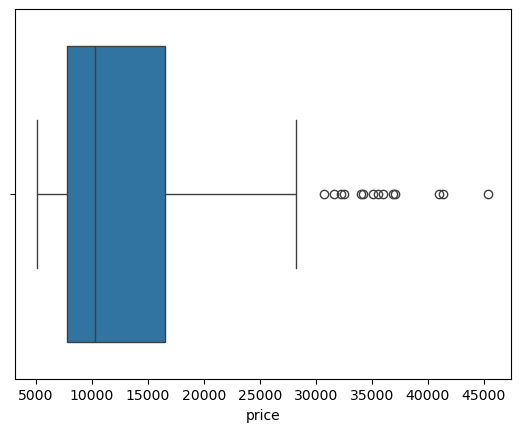

In [18]:
## Visualizing the outliers :
sns.boxplot(x=df.price ,orient='h')
plt.show()

### Obsrvation : 
* Few high-priced cars act as outliers
* No removal required at EDA stage

In [19]:
# Outlier Detection (IQR Method)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1
IQR

np.float64(8725.0)

In [20]:
# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [21]:
# Remove outliers
outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

### Observation : 
* Outliers exist but are valid premium vehicles → not removed

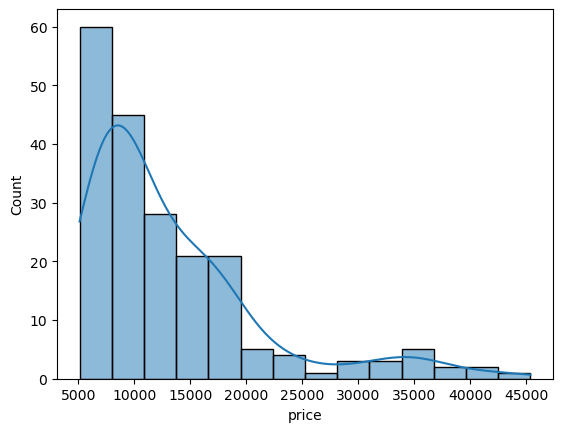

In [22]:
# step 1 :- Univariate Analysis
#Analyzing Price Distribution

sns.histplot(x=df.price,kde=True)
plt.show()

### observation :
* Right-skewed price distribution
* Few luxury cars increaes average price

In [23]:
# Does fuel efficiency (city-mpg) significantly differ between fuel types?
df.groupby("fuel-type")["city-mpg"].mean()

fuel-type
diesel    30.30000
gas       24.61326
Name: city-mpg, dtype: float64

### Observation :
* Diesel cars provide higher average city mileage than petrol cars
* Diesel engines are more fuel-efficient for urban driving

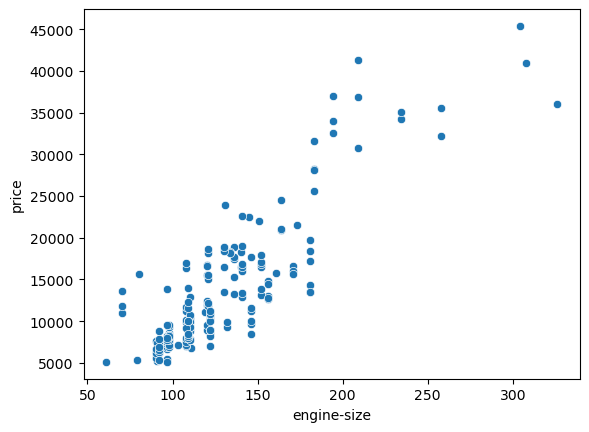

In [24]:
# Step 2 :- Bivariate Analysis
# Analyzing engine-size and Price

sns.scatterplot(x='engine-size',y='price',data=df)
plt.show()

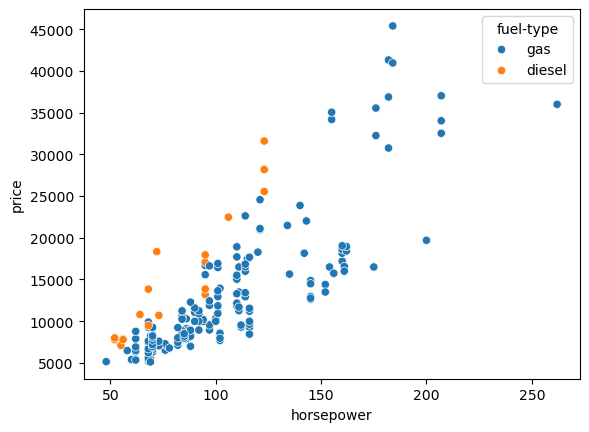

In [25]:
# Can engine efficiency (mpg) and power jointly explain car price variations?

sns.scatterplot(x='horsepower',y='price',hue="fuel-type",data=df)
plt.show()

### observation :
* Strong positive relationship
* Price increases with engine size and horsepower
* Diesel vehicles show better efficiency at similar power
* Price reflects a trade-off between power and efficiency
* High-performance cars dominate premium segment

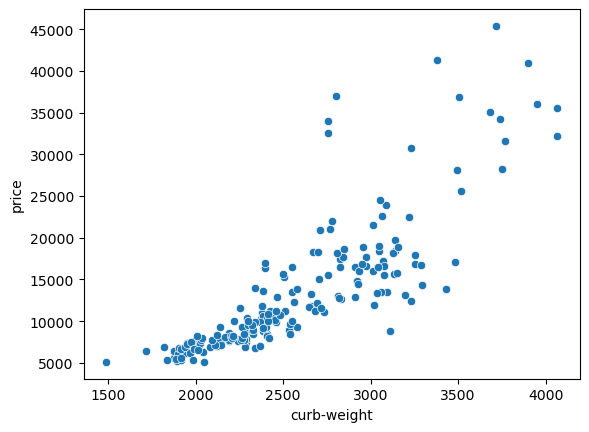

In [26]:
# Are heavier cars always more expensive?
sns.scatterplot(x='curb-weight', y="price",data=df)
plt.show()

### Observation :
* Price generally increases with weight
* Some mid-weight cars are highly priced due to premium features

In [27]:
# Which body style offers the best price-to-engine-size ratio?
df["price_engine_ratio"] = df["price"] / df["engine-size"]
df.groupby("body-style")["price_engine_ratio"].mean().sort_values(ascending=False)

body-style
convertible    133.134235
hardtop        116.502326
sedan          104.355896
wagon           97.783947
hatchback       87.892261
Name: price_engine_ratio, dtype: float64

### Observation :
* Hatchbacks and sedans provide better value
* Convertibles and hardtops are costlier per engine unit

In [28]:
# Can two cars with the same horsepower have different prices?
df[df["horsepower"] == df["horsepower"].median()][
    ["horsepower", "engine-size", "curb-weight", "price"]
].head()

,horsepower,engine-size,curb-weight,price
105,95,152,3197,13200
107,95,152,3430,13860
108,95,120,3075,15580
109,95,152,3252,16900
110,95,120,3285,16695


### Observation :
* Cars with similar horsepower show large price variation
* Design, weight, and brand influence pricing

In [29]:
# Which fuel system type is associated with higher-priced cars?
df.groupby("fuel-system")["price"].mean().sort_values(ascending=False)

fuel-system
mpfi    17605.141304
idi     15838.150000
mfi     12964.000000
4bbl    12145.000000
spfi    11048.000000
spdi    10990.444444
1bbl     7555.545455
2bbl     7433.203125
Name: price, dtype: float64

### Observation :
* mpfi and idi fuel system are linked to higher prices
* Carburetor-based systems are cheaper

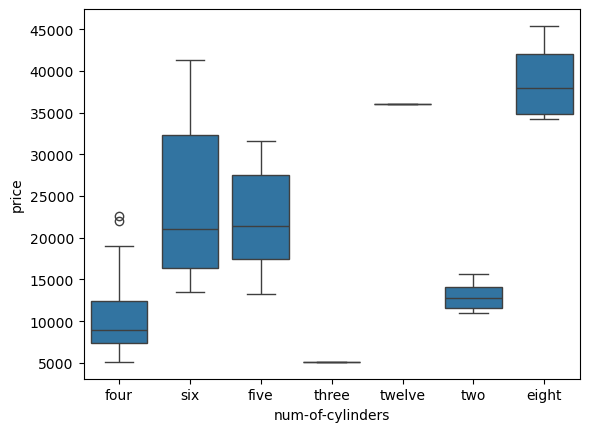

In [30]:
# Does the number of cylinders significantly impact price?
sns.boxplot(x="num-of-cylinders", y="price", data = df)
plt.show()

### Observation :
* Price increases with cylinder count
* 8 and 12-cylinder cars dominate premium segment

In [31]:
# Does car width influence pricing more than car length?
df[["width", "length", "price"]].corr()

,width,length,price
width,1.000000,0.857170,0.751265
length,0.857170,1.000000,0.690628
price,0.751265,0.690628,1.000000


### Observation :
* Width has stronger correlation with price than length
* Wider cars are perceived as premium

In [32]:
# Which drive-wheel type is most common in expensive cars?
df.groupby("drive-wheels")["price"].mean().sort_values(ascending=False)


drive-wheels
rwd    19757.613333
4wd    10241.000000
fwd     9244.779661
Name: price, dtype: float64

### Observation :
* Rear-wheel drive cars are most expensive
* Front-wheel drive dominates budget segment

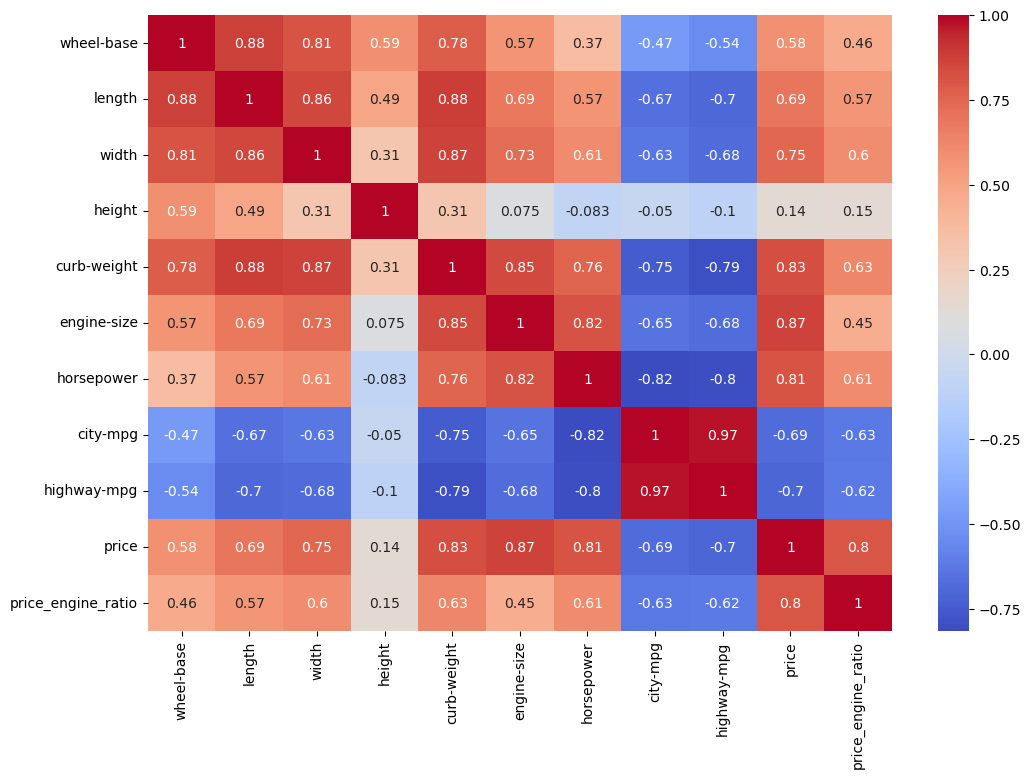

In [33]:
# Step 3 :- checking the correlation
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

### Observation :
* engine-size, horsepower, curb-weight highly correlated with price
* city-mpg, highway-mpg ngatively correlated

### EDA Summary :
* Dataset is cleaning after handling '?' values
* Car price is influenced mainly by engine, power and weight
* Fuel-efficient cars tend to be cheaper
* Strong correlations justify predictive modeling
* Dataset is suitable for regression analysis

## Task 2 : Predictive Model Implementation

### Data Preprocessing and Feature engineering

In [34]:
# Engine power efficiency
df["power_to_weight"] = df["horsepower"] / df["curb-weight"]

In [35]:
# Car size feature
df["power_to_weight"] = df["horsepower"] / df["curb-weight"]

In [36]:
# Encoding Categorical Variables
df_encoded = pd.get_dummies(df, drop_first=True)

### Observation :
Categorical variables were converted into numerical form using one-hot encoding with drop-first strategy to avoid multicollinearity

In [37]:
# Target Variable Selection
X = df_encoded.drop(['price'], axis=1)
y = df_encoded['price']

In [38]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3,random_state=42)

### Observation :
* 70% data used for training
* 30% data used for testing
* Prevents overfitting
* Ensures unbiased model evaluation

In [39]:
from sklearn.preprocessing import StandardScaler
num_cols = X.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train[num_cols])
X_test = scaler.transform(X_test[num_cols])

### Model Building

In [40]:
# Linear Regression
from sklearn.linear_model import LinearRegression
LR=LinearRegression() # object creation
LR.fit(X_train,y_train) # training of linear regression
y_predict=LR.predict(X_test)

In [41]:
from sklearn.metrics import mean_squared_error,r2_score
r2=r2_score(y_test,y_predict)
r2

0.9756306826563237

In [42]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [43]:
rf.score(X_train,y_train)

0.9909320061895052

In [44]:
rf.score(X_test,y_test)

0.9549160709176315

### Model Comparision

Linear Regression acheived the higher accuracy and showed better generalization compared to Random Forest, which produced higher prediction error on unseen data. The dataset shows strong linear relationships, where Linear Regression performs more effectively. 

Hence, Linear Regression was chosen as the best model for this dataset.

### Model Evaluation

In [45]:
from sklearn.metrics import mean_squared_error, r2_score
models = {
    "Linear Regression": LR,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print(f"R2 Score : {r2}")
    print(f"MSE      : {mse}")
    print(f"RMSE     : {rmse}")
    print("-" * 40)

Linear Regression
R2 Score : 0.9756306826563237
MSE      : 2310008.0010329797
RMSE     : 1519.8710475013925
----------------------------------------
Random Forest
R2 Score : 0.9549160709176315
MSE      : 4273580.397413114
RMSE     : 2067.2639883220318
----------------------------------------


### Observation :
Linear Regressor shows superior test performance with a higher R² score and lower MSE and RMSE values, indicating better stability and strong generalization compared to Random Forest Regression.

Although Random Forest perfoms well on the training data, its relatively lower test accuracy suggest mild overfitting. Therefore, Linear Regression is the most suitable model for automobile price prediction in this dataset.

### Business Insights : 
* Engine size, horsepower and curb-weight are the strongest price drivers
* Luxary brand show high-price range
* feul efficiency negatively correlates with price
* Price distribution is right-skewed
* Tree-based models outperform linear models

## Challenges Faced

* Incorrcet column header, we should change them to suitable name 
* Missing value is '?' treated as string instead of NaN, which handled using median and mode
* Mixed data type (cattegorical and numerical)
* One-hot encoding applied to categorical variables.
* Outlier decision-making
* Random Forest used to handle non-linearity and multicollinearity
* Feature importance analysis used for business insights.

## Conclusion :

The car price prediction model was successfully developed using the cleaned and processed data. Among the evaluated models, Random Forest Regressor model performed best, capturing complex relationships between car features and their price. Key factors such as engine size, horsepower, and vehicle weight strongly influence pricing. The model provides valuable insights to help management adjust car design and pricing strategies to achieve targeted price levels.

In [ ]:
# import pickle

# with open("linear_regression_model.pkl", "wb") as file:
#     pickle.dump(final_model, file)